# Model Training & Inference

# Load datasets

In [1]:
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')

# Root Path
ROOT = Path().resolve().parent

# Add src path folder for import
sys.path.append(str(ROOT / "src"))

# Load the Dataset
df = pd.read_csv(ROOT / "data" / "multi_class_df.csv",  encoding="utf-8-sig")
df.head()

c:\santosh\ABSA_project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,sentence,FOOD,PRICE,SERVICE,AMBIENCE
0,"수프는 치즈와 국수를 섞은 요리인데, 맛이 이상해서 별로 먹고 싶지 않아요.",1,0,0,0
1,만큼의 가치가 있어요.,0,2,0,0
2,"'유기농'이란 말이 '흙 맛'을 뜻한다고 생각한다면, 이것들민트은 당신에게 딱 맞습니다.",2,0,0,0
3,"( 아스파라거스, 트러플 오일, 파마산 브루스케타가 최고예요!)",2,0,0,0
4,( 항상 바텐더에게 계절 맥주를 요청하세요 !!!,2,0,0,0


### Split the dataset into Train, Val and Test

In [3]:
%pip install iterative-stratification


  Using cached iterative_stratification-0.1.9-py3-none-any.whl.metadata (1.3 kB)
Using cached iterative_stratification-0.1.9-py3-none-any.whl (8.5 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from data_processing.multilabel_split import split_data

aspects = ["FOOD", "PRICE", "SERVICE", "AMBIENCE"]
X = df["sentence"]
y = df[aspects]

X_train, y_train, X_val, y_val, X_test, y_test = split_data(X, y, aspects)
    
print("Train:", len(X_train))
print("Val:", len(X_val))
print("Test:", len(X_test))

Train: 2548
Val: 546
Test: 547


# 1. Traditional Machine Learning

Model:

- TF-IDF + Logistic Regression

Architecture:

2-stage approach

- Stage 1 → Aspect Mention Detection (0 vs non-0)

- Stage 2 → Sentiment Classification (1 vs 2)

### Training pipeline of TF-IDF + Logistic Regression


In [3]:
import time
import joblib
from sklearn.metrics import classification_report
from tfidf_lr.model import *     # Class TF-IDF + LR
from tfidf_lr.param_and_size import *   # Paramater and size function

# Train
# -------------------------------
start = time.time()
model = ABSATwoStageLR(aspects=aspects)
model.fit(X_train, y_train, X_val=X_val, y_val=y_val)
end = time.time()

total_training_time = end - start
print(f"\nTraining Time: {total_training_time:.2f} seconds")
print("Thresholds:", model.thresholds)

# Inference
# -------------------------------
eval_start = time.time()
y_pred = model.predict(X_test)   
eval_end = time.time()

total_eval_time = eval_end - eval_start
print(f"Evaluation Time: {total_eval_time:.2f} seconds")

# Parameter and size
lr_total, lr_per_aspect = count_params(model)
print("TF-IDF + LR total params:", lr_total)
print("Per-aspect:", lr_per_aspect)

lr_size = get_model_size(ROOT / "weights" / "lr_model.pkl")
print(f"LR model size: {lr_size:.2f} MB")



Training Time: 1.01 seconds
Thresholds: {'FOOD': 0.45000000000000007, 'PRICE': 0.45000000000000007, 'SERVICE': 0.5000000000000001, 'AMBIENCE': 0.5000000000000001}
Evaluation Time: 0.05 seconds
TF-IDF + LR total params: 192408
Per-aspect: {'FOOD': 48102, 'PRICE': 48102, 'SERVICE': 48102, 'AMBIENCE': 48102}
LR model size: 2.36 MB


In [ ]:
# Save model, prediction and results
# -------------------------------
joblib.dump(model, ROOT / "weights" / "lr_model.pkl")
print("\nModel saved as 'lr_model.pkl'")



Model saved as 'lr_model.pkl'


### Evaluation 

### Classification Report

In [30]:
from evaluation.classification_report import classification_analysis

aspects = ["FOOD", "PRICE", "SERVICE", "AMBIENCE"]
LABELS = [0, 1, 2]
LABEL_NAMES = ["NOT MENTION(0)", "NEGATIVE(1)", "POSITIVE(2)"]

y_true = y_test[aspects].reset_index(drop=True)
y_pred = y_pred[aspects].reset_index(drop=True)

# Classification Report
per_aspect_f1, macro_f1, macro_no0, mention_macro = classification_analysis(y_pred, y_true, aspects, LABELS, LABEL_NAMES )


===== FOOD : Classification Report (3-class) =====
                precision    recall  f1-score   support

NOT MENTION(0)     0.9188    0.8009    0.8558       226
   NEGATIVE(1)     0.6967    0.7143    0.7054       119
   POSITIVE(2)     0.7544    0.8515    0.8000       202

      accuracy                         0.8007       547
     macro avg     0.7900    0.7889    0.7871       547
  weighted avg     0.8098    0.8007    0.8025       547


===== PRICE : Classification Report (3-class) =====
                precision    recall  f1-score   support

NOT MENTION(0)     0.9759    0.9818    0.9789       495
   NEGATIVE(1)     0.7308    0.7917    0.7600        24
   POSITIVE(2)     0.6957    0.5714    0.6275        28

      accuracy                         0.9525       547
     macro avg     0.8008    0.7816    0.7888       547
  weighted avg     0.9508    0.9525    0.9513       547


===== SERVICE : Classification Report (3-class) =====
                precision    recall  f1-score   su

### Confusion Matrix

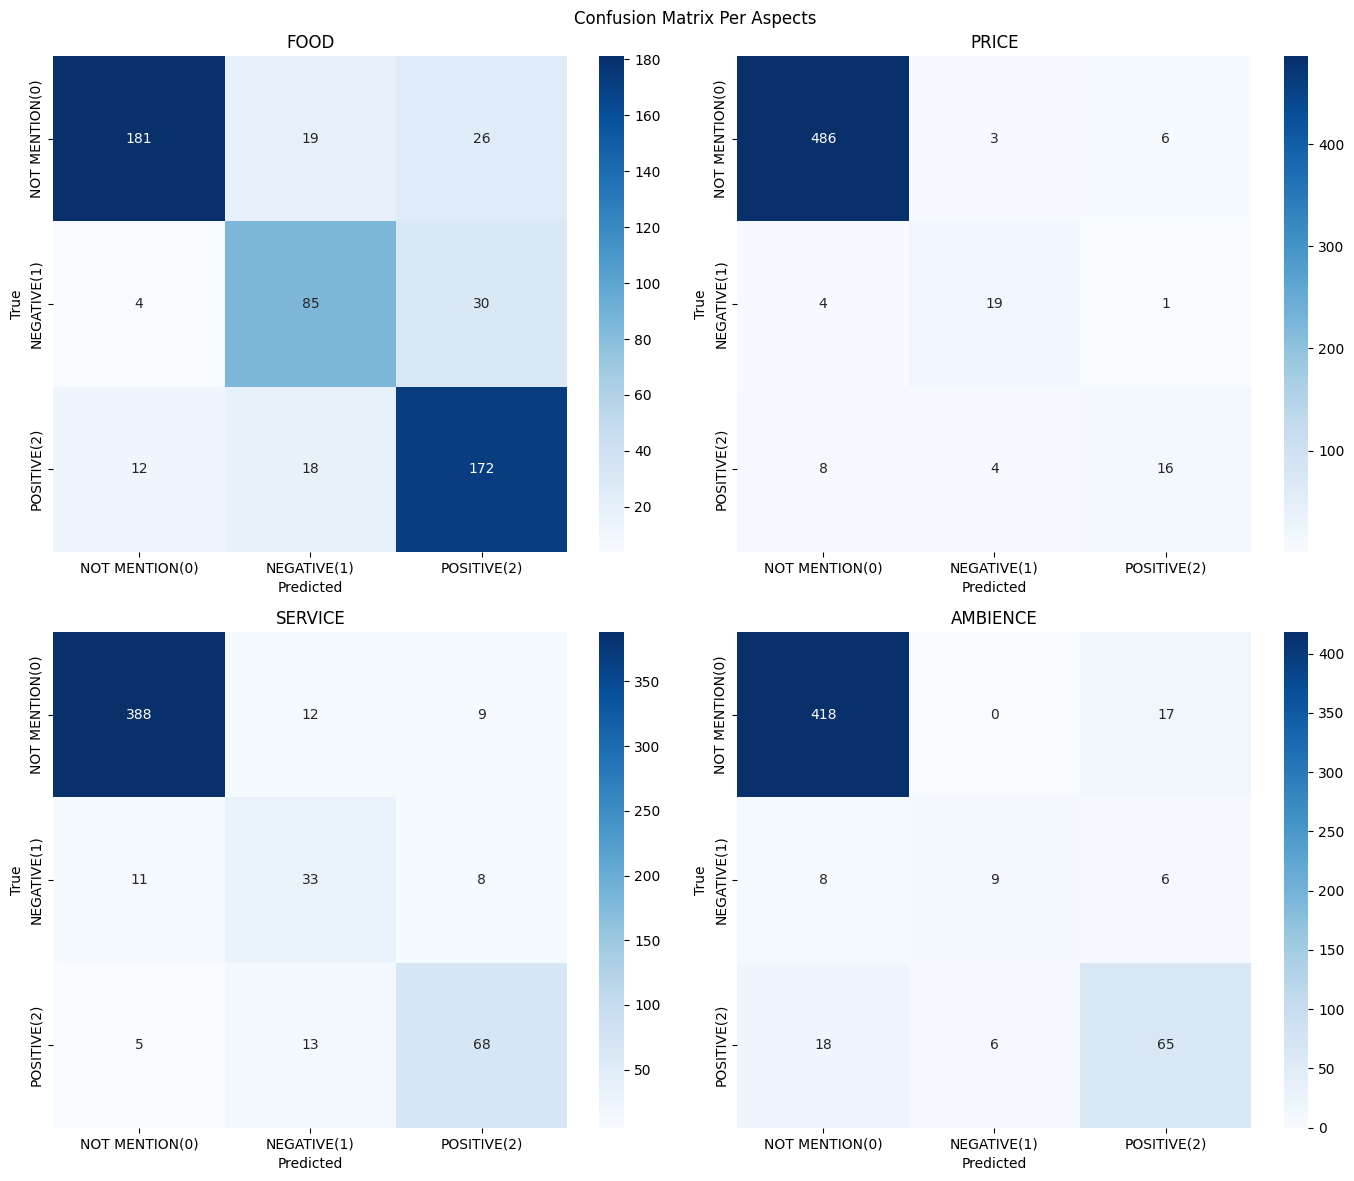

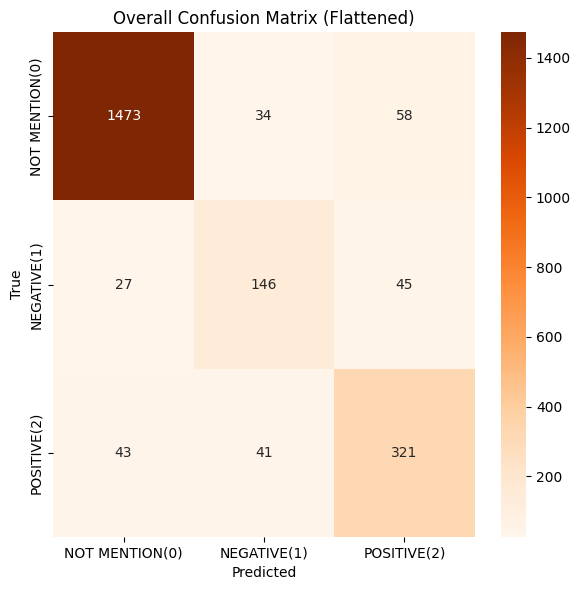

In [31]:
from evaluation.confusion_matrix import confusion_analysis

# Confusion Matrix
cm_all = confusion_analysis(y_pred, y_test, aspects, LABELS, LABEL_NAMES)

### Error Analysis

In [32]:
from evaluation.error_eval import error_analysis

# Error Analysis
misclassified_count = error_analysis(y_pred, y_test, X_test, aspects, top_n_errors=10)


Total misclassified aspect-decisions: 248
   row_id                                               text    aspect  \
0       0                                       만큼의 가치가 있어요.     PRICE   
1       4  첫 한 입의 맛은 정말 훌륭합니다... 조금 씹어보면 백악질의 콩 단백질 가루 맛만...      FOOD   
2       5  14살 아들과 대학생 조카에게 큰 인기를 끌었습니다. 조카도 학교에 여러 컵을 가져...      FOOD   
3       6                     55달러인분 저녁 식사에 이런 걸 기대하지는 않았네요.     PRICE   
4       9  레스토랑에서 점진적인 비용 절감이 이루어지는 이 시대에, 그러한 추세에 맞서 고품질...      FOOD   
5       9  레스토랑에서 점진적인 비용 절감이 이루어지는 이 시대에, 그러한 추세에 맞서 고품질...  AMBIENCE   
6      10              앉아서 먹는 멕시칸 음식과 시내 중심가 음식의 가격이 꽤 저렴해요.      FOOD   
7      12                   가격대비 만족도가 좋고, 매우 깨끗하고 괜찮습니다아침식사.      FOOD   
8      12                   가격대비 만족도가 좋고, 매우 깨끗하고 괜찮습니다아침식사.  AMBIENCE   
9      13                 가격대비 매우 좋음 조식 - 호텔 홈페이지에서 미리 예약하세요      FOOD   

   true_label  pred_label  
0           2           1  
1           1           2  
2           0           1  
3           2           1  
4 

In [18]:
# Save all the results
per_aspect_f1["model"] = "TFIDF_LR"
per_aspect_f1["macro_f1"] = macro_f1
per_aspect_f1_df = pd.DataFrame([per_aspect_f1])

file = ROOT / "results" / "per_aspect_results.csv"
per_aspect_f1_df.to_csv(file ,
    index=False,
    encoding="utf-8-sig"
)

result_file = ROOT / "results" / "combined_results.csv"
results = {
    "model": "TFIDF_LR",
    "sentiment_macro_f1": macro_no0,
    "mention_macro_f1": mention_macro,
    "training_time_sec": total_training_time,
    "evaluation_time_sec": total_eval_time,
    "misclassified_aspects":len(misclassified_count)
}
results_df = pd.DataFrame([results])
results_df.to_csv(result_file,
    index=False,
    encoding="utf-8-sig"
)


# 2. KcELECTRA Model
    This module implements a shared-encoder multi-task model for
Aspect-Based Sentiment Analysis (ABSA).


### Architecture
- One shared KcELECTRA encoder.
- The [CLS] representation is reused for all aspects.
- mention_head:

        Linear(hidden_size, num_aspects)
        Trained using multi-label BCE loss.

- sentiment_heads:

        One Linear(hidden_size, 2) per aspect.
        Trained using cross-entropy loss.
        Applied only when the aspect is mentioned.


In [4]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
# Make kc_electra folder importable directly
sys.path.append(str(ROOT / "src" / "kc_electra"))

# Import the class
from kc_electra.model import *    # Class SharedABSAWrapper with KcELECTRA model
from kc_electra.class_weights import compute_class_weights

# compute class weights
mention_pos_weight, sentiment_class_weights = compute_class_weights(y_train)

DEFAULT_MODEL   = "beomi/KcELECTRA-base-v2022"
DEFAULT_ASPECTS = ["FOOD", "PRICE", "SERVICE", "AMBIENCE"]
MAX_LENGTH      = 128
NUM_ASPECTS     = len(DEFAULT_ASPECTS)


# Call the model
model = SharedABSAWrapper(DEFAULT_MODEL, DEFAULT_ASPECTS,MAX_LENGTH,     mention_pos_weight=mention_pos_weight,
    sentiment_class_weights=sentiment_class_weights)

start = time.time()
model.fit(X_train, y_train, X_val, y_val)
elapsed = time.time() - start
print(f"Total Training Time: {elapsed:.1f}s")

start = time.time()
y_test_pred = model.predict(X_test)
inference_time = time.time() - start
print(f"Total evaluation time: {inference_time:1f}s")

# Save the model and predictions
model_file = ROOT / "weights" / "kc_electra"
model.save(model_file)

def count_pytorch_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# KcELECTRA
kc_total = count_pytorch_params(model.model)  
print("KcELECTRA total params:", kc_total)

kc_size = get_model_size(model_file /"kc_electra.pt")
print(f"KcELECTRA model size: {kc_size:.2f} MB")


Map:   0%|          | 0/2548 [00:00<?, ? examples/s]

Map:   0%|          | 0/546 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,E2e Macro F1
1,1.058800,0.728003,0.715547
2,0.565300,0.549378,0.825881
3,0.359800,0.489134,0.841522
4,0.252600,0.474745,0.858771
5,0.190300,0.478954,0.858658
6,0.152200,0.480989,0.873268


Total Training Time: 146.5s


Map:   0%|          | 0/547 [00:00<?, ? examples/s]

Total evaluation time: 1.040374s


In [6]:

def count_pytorch_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# KcELECTRA
kc_total = count_pytorch_params(model.model)  
print("KcELECTRA total params:", kc_total)

kc_size = get_model_size(model_file /"kc_electra.pt")
print(f"KcELECTRA model size: {kc_size:.2f} MB")


KcELECTRA total params: 127195404
KcELECTRA model size: 485.28 MB


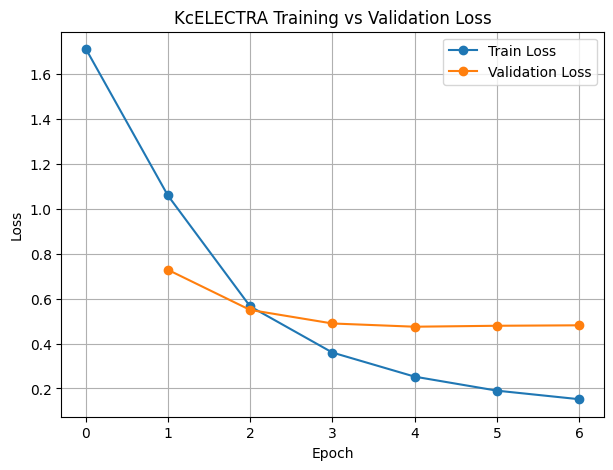

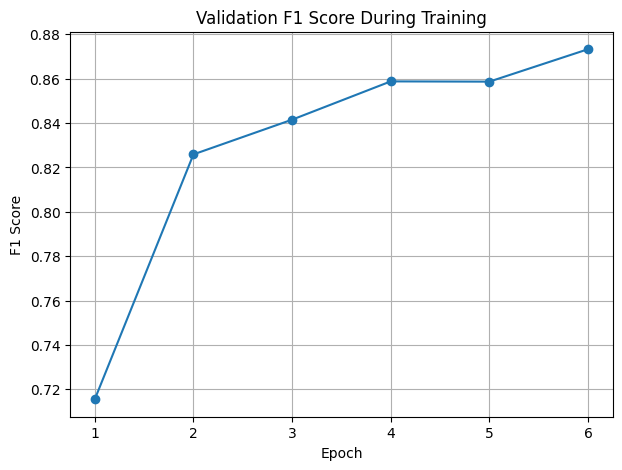

In [6]:
import pandas as pd

logs = pd.DataFrame(model.trainer.state.log_history)

# keep rows with epoch
logs = logs[logs["epoch"].notna()]

train_loss = logs[["epoch","loss"]].dropna()
val_loss   = logs[["epoch","eval_loss"]].dropna()
f1_score   = logs[["epoch","eval_e2e_macro_f1"]].dropna()
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(train_loss["epoch"], train_loss["loss"], marker="o", label="Train Loss")
plt.plot(val_loss["epoch"], val_loss["eval_loss"], marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("KcELECTRA Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()
print()
plt.figure(figsize=(7,5))

plt.plot(f1_score["epoch"], f1_score["eval_e2e_macro_f1"], marker="o")

plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Validation F1 Score During Training")
plt.grid(True)

plt.show()

In [9]:
from evaluation.classification_report import classification_analysis
aspects = ["FOOD", "PRICE", "SERVICE", "AMBIENCE"]
LABELS = [0, 1, 2]
LABEL_NAMES = ["NOT MENTION(0)", "NEGATIVE(1)", "POSITIVE(2)"]

y_true = y_test[aspects].reset_index(drop=True)
y_pred = y_test_pred[aspects].reset_index(drop=True)

# Classification Report
per_aspect_f1, macro_f1, macro_no0, mention_macro = classification_analysis(y_pred, y_true, aspects, LABELS, LABEL_NAMES )


===== FOOD : Classification Report (3-class) =====
                precision    recall  f1-score   support

NOT MENTION(0)     0.9704    0.8717    0.9184       226
   NEGATIVE(1)     0.8348    0.8067    0.8205       119
   POSITIVE(2)     0.8384    0.9505    0.8910       202

      accuracy                         0.8867       547
     macro avg     0.8812    0.8763    0.8766       547
  weighted avg     0.8922    0.8867    0.8870       547


===== PRICE : Classification Report (3-class) =====
                precision    recall  f1-score   support

NOT MENTION(0)     0.9666    0.9939    0.9801       495
   NEGATIVE(1)     0.9412    0.6667    0.7805        24
   POSITIVE(2)     0.8095    0.6071    0.6939        28

      accuracy                         0.9598       547
     macro avg     0.9058    0.7559    0.8181       547
  weighted avg     0.9574    0.9598    0.9567       547


===== SERVICE : Classification Report (3-class) =====
                precision    recall  f1-score   su

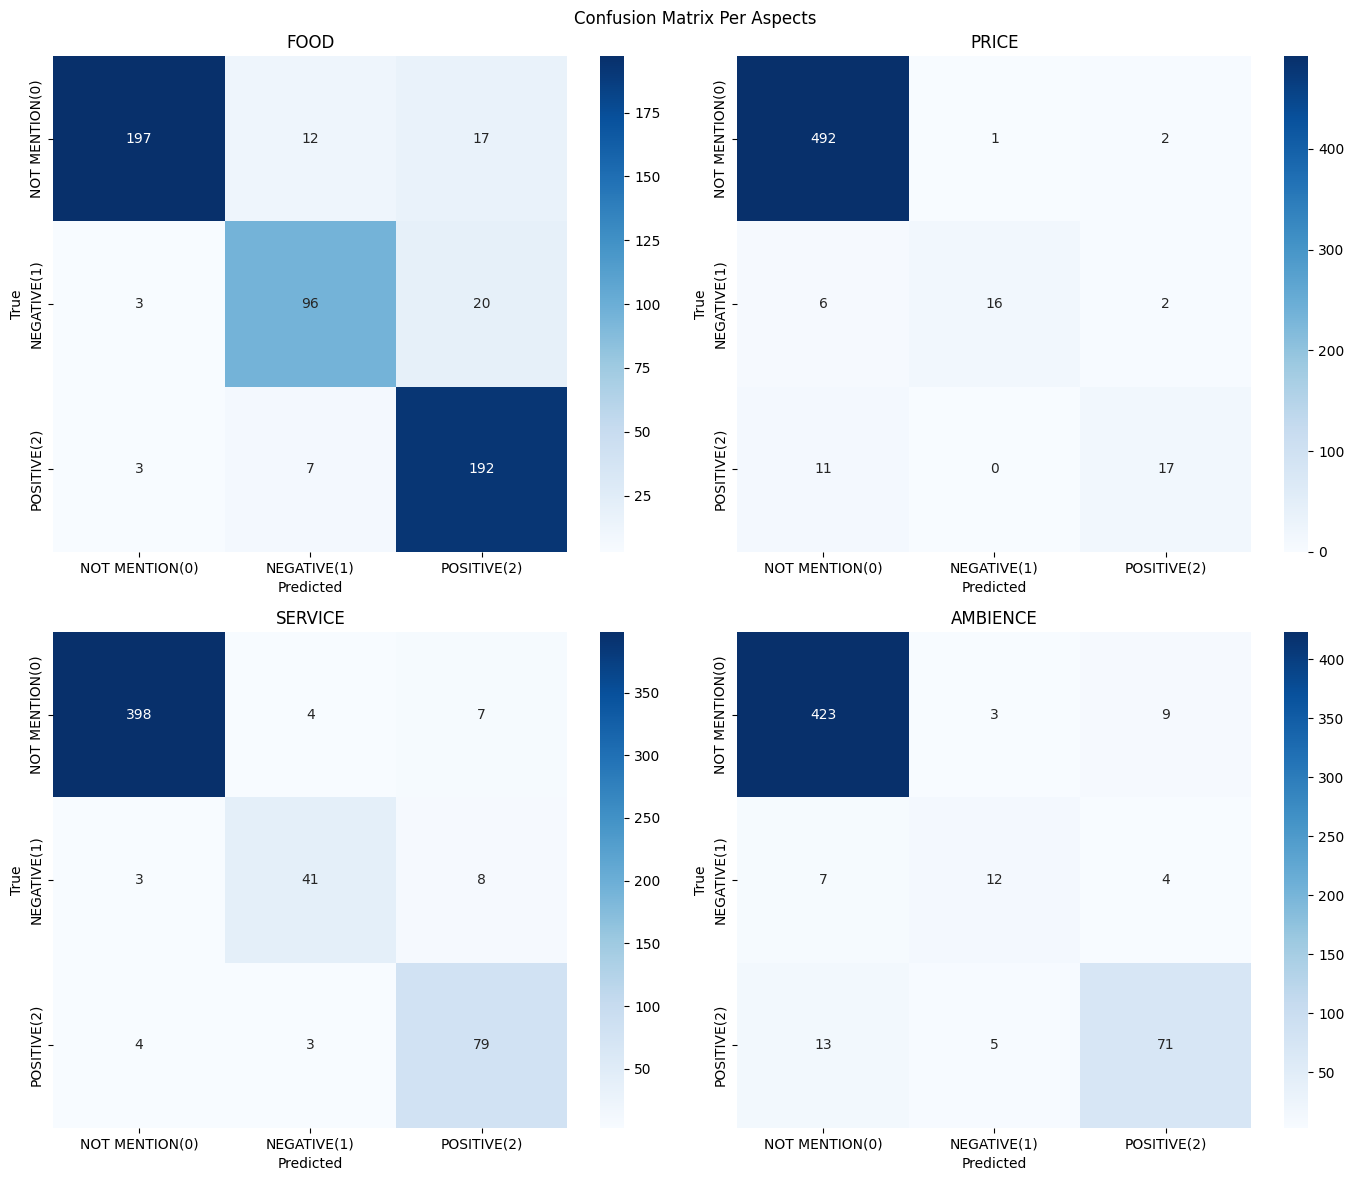

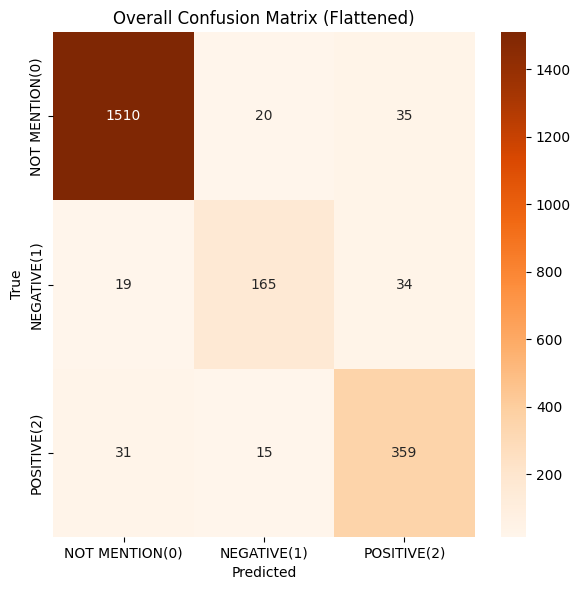

In [14]:
from evaluation.confusion_matrix import confusion_analysis

# Confusion Matrix
cm_all = confusion_analysis(y_pred, y_test, aspects, LABELS, LABEL_NAMES)

In [16]:
from evaluation.error_eval import error_analysis

# Error Analysis
misclassified_count = error_analysis(y_pred, y_test, X_test, aspects, top_n_errors=10)


Total misclassified aspect-decisions: 154
   row_id                                               text    aspect  \
0       0                                       만큼의 가치가 있어요.     PRICE   
1       4  첫 한 입의 맛은 정말 훌륭합니다... 조금 씹어보면 백악질의 콩 단백질 가루 맛만...      FOOD   
2       5  14살 아들과 대학생 조카에게 큰 인기를 끌었습니다. 조카도 학교에 여러 컵을 가져...      FOOD   
3       6                     55달러인분 저녁 식사에 이런 걸 기대하지는 않았네요.     PRICE   
4      10              앉아서 먹는 멕시칸 음식과 시내 중심가 음식의 가격이 꽤 저렴해요.      FOOD   
5      12                   가격대비 만족도가 좋고, 매우 깨끗하고 괜찮습니다아침식사.     PRICE   
6      12                   가격대비 만족도가 좋고, 매우 깨끗하고 괜찮습니다아침식사.  AMBIENCE   
7      16                         가격은 서비스와 음식의 질에 비해 저렴했습니다.   SERVICE   
8      17  가격이 너무 낮아서 중국에서 만든 쓰레기 제품일 수도 있다고 의심하는데, 이는 중국...      FOOD   
9      17  가격이 너무 낮아서 중국에서 만든 쓰레기 제품일 수도 있다고 의심하는데, 이는 중국...     PRICE   

   true_label  pred_label  
0           2           0  
1           1           2  
2           0           2  
3           2           0  
4 

In [19]:
import os

# Save all the results
per_aspect_f1["model"] = "KcELECTRA"
per_aspect_f1["macro_f1"] = macro_f1
new_row = pd.DataFrame([per_aspect_f1])

file = ROOT / "results" / "per_aspect_results.csv"

if os.path.exists(file):
    old = pd.read_csv(file)
    df = pd.concat([old, new_row], ignore_index=True)
    df.to_csv(file, index=False)

result_file = ROOT / "results" / "combined_results.csv"
results = {
    "model": "KcELECTRA",
    "sentiment_macro_f1": macro_no0,
    "mention_macro_f1": mention_macro,
    "training_time_sec": elapsed,
    "evaluation_time_sec": inference_time,
    "misclassified_aspects": len(misclassified_count)
}
electra_results = pd.DataFrame([results])
if os.path.exists(result_file):
    old_result = pd.read_csv(result_file)
    df = pd.concat([old_result, electra_results], ignore_index=True)
    df.to_csv(result_file, index=False)

# 3. Ollama LLM

In [ ]:
import time

# Make ollama_llm folder importable directly
sys.path.append(str(ROOT / "src" / "ollama_llm"))

from inference import predict_llm_batch

start = time.time()
y_pred_llm = predict_llm_batch(X_test)
total_time = time.time() - start

print("Total inference time:", total_time)



100%|██████████| 547/547 [30:01<00:00,  3.29s/it]

Total inference time: 1801.812245130539


In [20]:
aspects = ["FOOD", "PRICE", "SERVICE", "AMBIENCE"]
LABELS = [0, 1, 2]
LABEL_NAMES = ["NOT MENTION(0)", "NEGATIVE(1)", "POSITIVE(2)"]

y_true = y_test[aspects].reset_index(drop=True)
y_pred = y_pred_llm[aspects].reset_index(drop=True)

# Classification Report
per_aspect_f1, macro_f1, macro_no0, mention_macro = classification_analysis(y_pred, y_true, aspects, LABELS, LABEL_NAMES )


===== FOOD : Classification Report (3-class) =====
                precision    recall  f1-score   support

NOT MENTION(0)     0.7318    0.5796    0.6469       226
   NEGATIVE(1)     0.9630    0.2185    0.3562       119
   POSITIVE(2)     0.5103    0.8614    0.6409       202

      accuracy                         0.6051       547
     macro avg     0.7350    0.5532    0.5480       547
  weighted avg     0.7003    0.6051    0.5814       547


===== PRICE : Classification Report (3-class) =====
                precision    recall  f1-score   support

NOT MENTION(0)     0.9910    0.8909    0.9383       495
   NEGATIVE(1)     0.3485    0.9583    0.5111        24
   POSITIVE(2)     0.5556    0.7143    0.6250        28

      accuracy                         0.8848       547
     macro avg     0.6317    0.8545    0.6915       547
  weighted avg     0.9405    0.8848    0.9035       547


===== SERVICE : Classification Report (3-class) =====
                precision    recall  f1-score   su

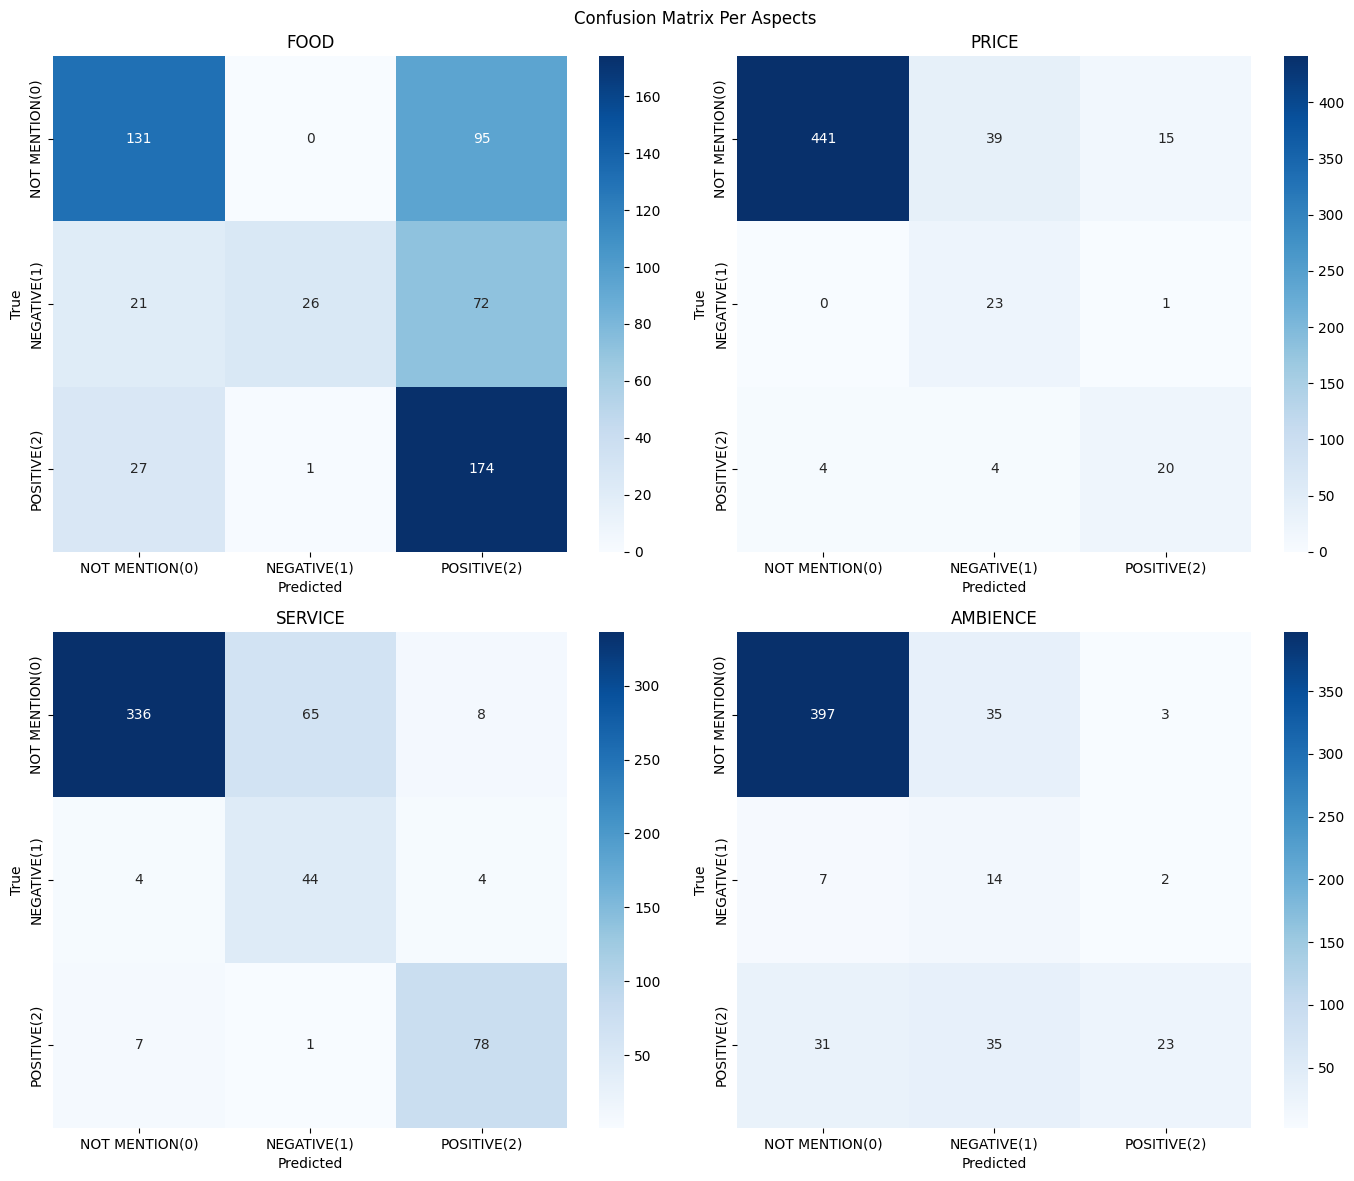

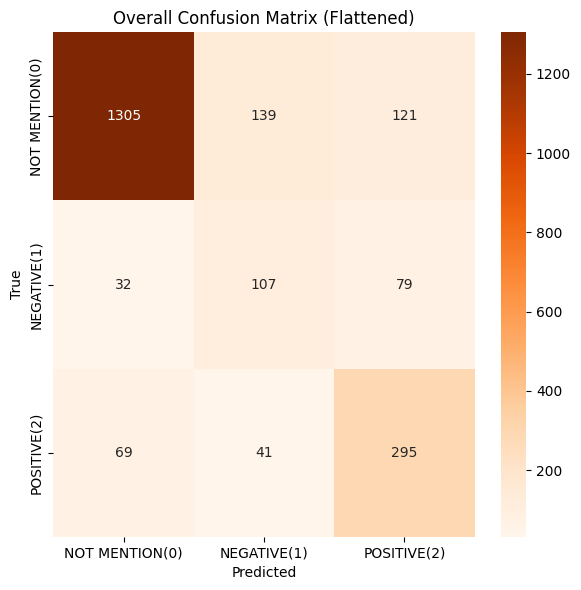

In [23]:
from evaluation.confusion_matrix import confusion_analysis

# Confusion Matrix
cm_all = confusion_analysis(y_pred, y_test, aspects, LABELS, LABEL_NAMES)

In [24]:
# Error Analysis
misclassified_count = error_analysis(y_pred, y_test, X_test, aspects, top_n_errors=10)


Total misclassified aspect-decisions: 481
   row_id                                               text    aspect  \
0       0                                       만큼의 가치가 있어요.     PRICE   
1       4  첫 한 입의 맛은 정말 훌륭합니다... 조금 씹어보면 백악질의 콩 단백질 가루 맛만...      FOOD   
2       4  첫 한 입의 맛은 정말 훌륭합니다... 조금 씹어보면 백악질의 콩 단백질 가루 맛만...   SERVICE   
3       5  14살 아들과 대학생 조카에게 큰 인기를 끌었습니다. 조카도 학교에 여러 컵을 가져...      FOOD   
4       6                     55달러인분 저녁 식사에 이런 걸 기대하지는 않았네요.      FOOD   
5       6                     55달러인분 저녁 식사에 이런 걸 기대하지는 않았네요.     PRICE   
6       7       GF가 아닌 우리 가족은 일반(독) 프레즐보다 글루티노 프레즐을 더 선호합니다.      FOOD   
7       9  레스토랑에서 점진적인 비용 절감이 이루어지는 이 시대에, 그러한 추세에 맞서 고품질...     PRICE   
8       9  레스토랑에서 점진적인 비용 절감이 이루어지는 이 시대에, 그러한 추세에 맞서 고품질...  AMBIENCE   
9      10              앉아서 먹는 멕시칸 음식과 시내 중심가 음식의 가격이 꽤 저렴해요.      FOOD   

   true_label  pred_label  
0           2           1  
1           1           2  
2           0           1  
3           0           2  
4 

### Save the results

In [25]:
import os

# Save all the results
per_aspect_f1["model"] = "Qwen"
per_aspect_f1["macro_f1"] = macro_f1
new_row = pd.DataFrame([per_aspect_f1])

file = ROOT / "results" / "per_aspect_results.csv"

if os.path.exists(file):
    old = pd.read_csv(file)
    df = pd.concat([old, new_row], ignore_index=True)
    df.to_csv(file, index=False)

result_file = ROOT / "results" / "combined_results.csv"
results = {
    "model": "Qwen",
    "sentiment_macro_f1": macro_no0,
    "mention_macro_f1": mention_macro,
    "training_time_sec": 0,
    "evaluation_time_sec": total_time,
    "misclassified_aspects": len(misclassified_count)
}
electra_results = pd.DataFrame([results])
if os.path.exists(result_file):
    old_result = pd.read_csv(result_file)
    df = pd.concat([old_result, electra_results], ignore_index=True)
    df.to_csv(result_file, index=False)

# Inference with Hard Examples()


In [5]:
# Load the sarcasm data
example_df = pd.read_csv(ROOT / "data" / "hard_example_set.csv")

# Separate features (X) and labels (y)
X = example_df["sentence"].values
y = example_df[["FOOD", "PRICE", "SERVICE", "AMBIENCE"]].values

# Load all the models
from evaluation.load_models import load_models
lr_model, kc_model = load_models()

# Predict for lr and kc model
y_pred_lr_model = lr_model.predict(X)
y_pred_kc_model = kc_model.predict(X)

# Predict for qwen model
from ollama_llm.inference import predict_llm_batch
y_pred_qwen = predict_llm_batch(X)


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 16078.89it/s]
ElectraModel LOAD REPORT from: beomi/KcELECTRA-base-v2022
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
discriminator_predictions.dense.weight            | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED |  | 
discriminator_predictions.dense.bias              | UNEXPECTED |  | 
electra.embeddings.position_ids                   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 28/28 [01:31<00:00,  3.26s/it]


In [6]:
aspect_names = ["FOOD", "PRICE", "SERVICE", "AMBIENCE"]
lr_errors = []
kc_errors = []
qwen_errors = []


for i, aspect in enumerate(aspect_names):
    mask = y[:, i] != 0  # only where aspect is mentioned

    total_present = np.sum(mask)

    lr_mis = np.sum((y_pred_lr_model.iloc[:, i] != y[:, i]) & mask)
    kc_mis = np.sum((y_pred_kc_model.iloc[:, i] != y[:, i]) & mask)
    qwen_mis = np.sum((y_pred_qwen.iloc[:, i] != y[:, i]) & mask)

    lr_errors.append((lr_mis / total_present) * 100 if total_present > 0 else 0)
    kc_errors.append((kc_mis / total_present) * 100 if total_present > 0 else 0)
    qwen_errors.append((qwen_mis / total_present) * 100 if total_present > 0 else 0)
    print(f"{aspect}: LR={lr_mis}, KC={kc_mis}, Qwen={qwen_mis}")

FOOD: LR=12, KC=6, Qwen=5
PRICE: LR=3, KC=3, Qwen=1
SERVICE: LR=4, KC=4, Qwen=2
AMBIENCE: LR=11, KC=6, Qwen=4


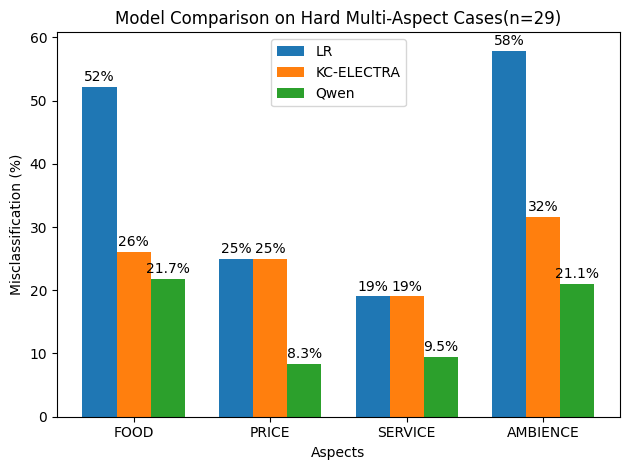

In [15]:
import numpy as np
import matplotlib.pyplot as plt


x = np.arange(len(aspect_names))
width = 0.25

plt.figure()

# store bar containers
bars_lr = plt.bar(x - width, lr_errors, width, label="LR")
bars_kc = plt.bar(x, kc_errors, width, label="KC-ELECTRA")
bars_qwen = plt.bar(x + width, qwen_errors, width, label="Qwen")

plt.xticks(x, aspect_names)
plt.xlabel("Aspects")
plt.ylabel("Misclassification (%)")
plt.title("Model Comparison on Hard Multi-Aspect Cases(n=29)")
plt.legend()

# add labels
plt.bar_label(bars_lr, fmt="%.f%%", padding=2)
plt.bar_label(bars_kc, fmt="%.f%%", padding=2)
plt.bar_label(bars_qwen, fmt="%.1f%%", padding=2)
plt.tight_layout()

plt.show()

### Overall, Qwen demonstrated a relative advantage on these hard cases, achieving the lowest total misclassifications across most aspects. While KcELECTRA remained competitive. On the other hand, TF-IDF underperforms having most misclassifications.